# CNN Models Fine-tuning for Egyptian Landmarks Classification (v2)

**Models included:**
- EfficientNet-B4
- ResNet-101
- InceptionResNet-V2

## 1. Imports and Setup

In [1]:
import os
import random
import numpy as np
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler  # Updated import

import torchvision.transforms as T
from torchvision import models
from PIL import Image

import timm  # For InceptionResNetV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Using device: cuda


## 2. Configuration

In [2]:
# Setup paths - Kaggle
DATASET_PATH = Path('/kaggle/input/updated-landmark-data/images')
SAVE_DIR = Path('/kaggle/working/cnn_egypt_models')
SAVE_DIR.mkdir(exist_ok=True, parents=True)

# Configuration matching CLIP notebook
CONFIG = {
    'min_images': 15,
    'batch_size': 8,
    'accumulation_steps': 4,
    'epochs': 50,
    'lr': 1e-4,
    'warmup_epochs': 2,
    'patience': 5,
    'num_workers': 2,
    'unfreeze_layers': 20,
    'use_amp': True,
    'img_size': 224,
    'max_grad_norm': 1.0,  # NEW: gradient clipping threshold
}

# Model-specific learning rate multipliers (inception is more sensitive)
LR_MULTIPLIERS = {
    'efficientnet_b4': 1.0,
    'resnet101': 1.0,
    'inception_resnet_v2': 0.5,  # Lower LR for stability
}

print(f"Config: {CONFIG}")

Config: {'min_images': 15, 'batch_size': 8, 'accumulation_steps': 4, 'epochs': 50, 'lr': 0.0001, 'warmup_epochs': 2, 'patience': 5, 'num_workers': 2, 'unfreeze_layers': 20, 'use_amp': True, 'img_size': 224, 'max_grad_norm': 1.0}


## 3. Data Loading with Class Filtering

In [3]:
def load_dataset_with_filter(dataset_path, min_images=5):
    """Load dataset and filter classes with minimum images."""
    all_images = []
    all_labels = []
    class_names = []
    
    class_dirs = sorted([d for d in dataset_path.iterdir() if d.is_dir()])
    
    class_counts = {}
    for class_dir in class_dirs:
        images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpeg'))
        class_counts[class_dir.name] = len(images)
    
    valid_classes = [name for name, count in class_counts.items() if count >= min_images]
    valid_classes = sorted(valid_classes)
    class_to_idx = {name: idx for idx, name in enumerate(valid_classes)}
    
    print(f"Original classes: {len(class_counts)}")
    print(f"Classes with >= {min_images} images: {len(valid_classes)}")
    
    for class_name in valid_classes:
        class_dir = dataset_path / class_name
        images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpeg'))
        for img_path in images:
            all_images.append(str(img_path))
            all_labels.append(class_to_idx[class_name])
    
    print(f"Total images: {len(all_images)}")
    
    return all_images, all_labels, valid_classes, class_to_idx

# Load dataset
all_images, all_labels, class_names, class_to_idx = load_dataset_with_filter(
    DATASET_PATH, CONFIG['min_images']
)
NUM_CLASSES = len(class_names)
print(f"Number of classes: {NUM_CLASSES}")

Original classes: 278
Classes with >= 15 images: 110
Total images: 4342
Number of classes: 110


## 4. Data Augmentation

In [4]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = T.Compose([
    T.RandomResizedCrop(CONFIG['img_size'], scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(CONFIG['img_size']),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transforms configured.")

Transforms configured.


## 5. Dataset and DataLoaders

In [5]:
class LandmarkDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            return torch.zeros(3, CONFIG['img_size'], CONFIG['img_size']), label

In [6]:
# Stratified train/val/test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    all_images, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, stratify=y_trainval, random_state=42
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

train_dataset = LandmarkDataset(X_train, y_train, train_transform)
val_dataset = LandmarkDataset(X_val, y_val, val_transform)
test_dataset = LandmarkDataset(X_test, y_test, val_transform)

train_loader = DataLoader(
    train_dataset, batch_size=CONFIG['batch_size'], 
    shuffle=True, num_workers=CONFIG['num_workers'], pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=CONFIG['batch_size'], 
    shuffle=False, num_workers=CONFIG['num_workers'], pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=CONFIG['batch_size'], 
    shuffle=False, num_workers=CONFIG['num_workers'], pin_memory=True
)

print("DataLoaders created.")

Train: 2778, Val: 695, Test: 869
DataLoaders created.


## 6. Model Architectures

In [7]:
class CNNClassifier(nn.Module):
    """CNN classifier with custom head."""
    
    def __init__(self, backbone_name, num_classes, pretrained=True, unfreeze_layers=20):
        super().__init__()
        self.backbone_name = backbone_name
        
        if backbone_name == 'efficientnet_b4':
            weights = models.EfficientNet_B4_Weights.IMAGENET1K_V1 if pretrained else None
            self.backbone = models.efficientnet_b4(weights=weights)
            self.feature_dim = self.backbone.classifier[1].in_features
            self.backbone.classifier = nn.Identity()
            
        elif backbone_name == 'resnet101':
            weights = models.ResNet101_Weights.IMAGENET1K_V2 if pretrained else None
            self.backbone = models.resnet101(weights=weights)
            self.feature_dim = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
            
        elif backbone_name == 'inception_resnet_v2':
            self.backbone = timm.create_model('inception_resnet_v2', pretrained=pretrained, num_classes=0)
            self.feature_dim = self.backbone.num_features
            
        else:
            raise ValueError(f"Unknown backbone: {backbone_name}")
        
        self._freeze_backbone(unfreeze_layers)
        
        self.classifier = nn.Sequential(
            nn.Linear(self.feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def _freeze_backbone(self, unfreeze_layers):
        """Freeze backbone except last N layers."""
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        all_params = list(self.backbone.parameters())
        
        for param in all_params[-unfreeze_layers:]:
            param.requires_grad = True
        
        trainable = sum(p.numel() for p in self.backbone.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.backbone.parameters())
        print(f"{self.backbone_name}: Trainable backbone params: {trainable:,} / {total:,}")
    
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

# Test model creation
test_model = CNNClassifier('efficientnet_b4', NUM_CLASSES, unfreeze_layers=CONFIG['unfreeze_layers'])
print(f"Classifier params: {sum(p.numel() for p in test_model.classifier.parameters()):,}")
del test_model

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 168MB/s]


efficientnet_b4: Trainable backbone params: 4,589,264 / 17,548,616
Classifier params: 487,278


## 7. Training Functions

In [8]:
def get_warmup_lr(epoch, warmup_epochs, base_lr):
    """Linear warmup learning rate."""
    if epoch < warmup_epochs:
        return base_lr * (epoch + 1) / warmup_epochs
    return base_lr

def train_one_epoch(model, loader, criterion, optimizer, scaler, epoch, config):
    """Train for one epoch with gradient accumulation, mixed precision, and gradient clipping."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    nan_batches = 0
    
    # Learning rate warmup
    if epoch < config['warmup_epochs']:
        lr = get_warmup_lr(epoch, config['warmup_epochs'], config['current_lr'])
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr
    
    optimizer.zero_grad()
    
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}")
    for batch_idx, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)
        
        # Mixed precision forward
        with autocast('cuda', enabled=config['use_amp']):
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss = loss / config['accumulation_steps']
        
        # Check for NaN loss
        if torch.isnan(loss):
            nan_batches += 1
            print(f"Warning: NaN loss at batch {batch_idx}, skipping...")
            optimizer.zero_grad()
            continue
        
        # Backward
        scaler.scale(loss).backward()
        
        # Gradient accumulation with clipping
        if (batch_idx + 1) % config['accumulation_steps'] == 0:
            # Unscale gradients before clipping
            scaler.unscale_(optimizer)
            # Clip gradients to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config['max_grad_norm'])
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        
        # Metrics
        total_loss += loss.item() * config['accumulation_steps']
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({
            'loss': f"{total_loss/(batch_idx+1):.4f}",
            'acc': f"{100.*correct/total:.2f}%"
        })
    
    if nan_batches > 0:
        print(f"Warning: {nan_batches} batches had NaN loss and were skipped.")
    
    return total_loss / len(loader), 100. * correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, use_amp=True):
    """Evaluate model on a dataset with NaN handling."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    for images, labels in tqdm(loader, desc="Evaluating"):
        images, labels = images.to(device), labels.to(device)
        
        with autocast('cuda', enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        # Convert to float32 before softmax for numerical stability
        outputs_fp32 = outputs.float()
        
        total_loss += loss.item()
        probs = torch.softmax(outputs_fp32, dim=1)
        _, predicted = outputs_fp32.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    
    accuracy = 100. * correct / total
    avg_loss = total_loss / len(loader)
    
    # Convert to numpy array for NaN checking
    all_probs = np.array(all_probs)
    
    # Handle NaN in predictions
    nan_count = np.isnan(all_probs).sum()
    if nan_count > 0:
        print(f"Warning: NaN detected in {nan_count} prediction values. Replacing with zeros.")
        all_probs = np.nan_to_num(all_probs, nan=0.0)
        # Re-normalize rows to sum to 1
        row_sums = all_probs.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1  # Avoid division by zero
        all_probs = all_probs / row_sums
    
    # Top-5 accuracy
    top5_acc = top_k_accuracy_score(all_labels, all_probs, k=5) * 100
    
    return avg_loss, accuracy, top5_acc, all_preds, all_labels

## 8. Main Training Loop

In [9]:
def train_model(backbone_name, config, train_loader, val_loader, test_loader, num_classes):
    """Full training pipeline for a model."""
    print(f"\n{'='*60}")
    print(f"Training {backbone_name}")
    print(f"{'='*60}")
    
    # Create model
    model = CNNClassifier(
        backbone_name, num_classes, 
        pretrained=True, 
        unfreeze_layers=config['unfreeze_layers']
    ).to(device)
    
    # Adjust learning rate based on model
    lr_multiplier = LR_MULTIPLIERS.get(backbone_name, 1.0)
    current_lr = config['lr'] * lr_multiplier
    print(f"Using learning rate: {current_lr} (multiplier: {lr_multiplier})")
    
    # Store current LR in config for warmup
    config_copy = config.copy()
    config_copy['current_lr'] = current_lr
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=current_lr, weight_decay=0.01)
    scaler = GradScaler('cuda', enabled=config['use_amp'])
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config['epochs'] - config['warmup_epochs']
    )
    
    # Training history
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [], 'val_top5': []
    }
    
    best_val_acc = 0
    patience_counter = 0
    
    for epoch in range(config['epochs']):
        # Train
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, epoch, config_copy
        )
        
        # Validate
        val_loss, val_acc, val_top5, _, _ = evaluate(
            model, val_loader, criterion, use_amp=config['use_amp']
        )
        
        # Update scheduler after warmup
        if epoch >= config['warmup_epochs']:
            scheduler.step()
        
        # Record history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_top5'].append(val_top5)
        
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}%, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%, Val Top5={val_top5:.2f}%")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'config': config,
            }, SAVE_DIR / f"{backbone_name}_best.pt")
            print(f"  -> New best model saved! Val Acc: {val_acc:.2f}%")
        else:
            patience_counter += 1
        
        # Early stopping
        if patience_counter >= config['patience']:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # Load best model for final evaluation
    checkpoint = torch.load(SAVE_DIR / f"{backbone_name}_best.pt")
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Final test evaluation
    test_loss, test_acc, test_top5, test_preds, test_labels = evaluate(
        model, test_loader, criterion, use_amp=config['use_amp']
    )
    
    print(f"\nFinal Test Results for {backbone_name}:")
    print(f"  Test Accuracy: {test_acc:.2f}%")
    print(f"  Test Top-5 Accuracy: {test_top5:.2f}%")
    
    return model, history, {
        'test_acc': test_acc,
        'test_top5': test_top5,
        'best_val_acc': best_val_acc
    }

## 9. Train All Models

In [10]:
# Models to train
MODELS_TO_TRAIN = ['efficientnet_b4', 'resnet101', 'inception_resnet_v2']

# Store results
all_results = {}
all_histories = {}

for backbone_name in MODELS_TO_TRAIN:
    model, history, results = train_model(
        backbone_name, CONFIG, 
        train_loader, val_loader, test_loader, 
        NUM_CLASSES
    )
    all_results[backbone_name] = results
    all_histories[backbone_name] = history
    
    # Clear memory
    del model
    torch.cuda.empty_cache()


Training efficientnet_b4
efficientnet_b4: Trainable backbone params: 4,589,264 / 17,548,616
Using learning rate: 0.0001 (multiplier: 1.0)


Epoch 1:   0%|          | 0/348 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/87 [00:00<?, ?it/s]

Epoch 1: Train Loss=4.6833, Train Acc=2.27%, Val Loss=4.6573, Val Acc=5.76%, Val Top5=19.57%
  -> New best model saved! Val Acc: 5.76%


Epoch 2:   0%|          | 0/348 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/87 [00:00<?, ?it/s]

Epoch 28: Train Loss=2.4124, Train Acc=42.08%, Val Loss=nan, Val Acc=23.31%, Val Top5=41.44%
Early stopping at epoch 28


Evaluating:   0%|          | 0/109 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e7773486700>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process' 
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e7773486700>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


Final Test Results for inception_resnet_v2:
  Test Accuracy: 27.50%
  Test Top-5 Accuracy: 49.02%


## 10. Results Comparison

In [11]:
# Print comparison table
print("\n" + "="*70)
print("RESULTS COMPARISON")
print("="*70)
print(f"{'Model':<25} {'Test Acc':<12} {'Top-5 Acc':<12} {'Best Val Acc':<12}")
print("-"*70)

for model_name, results in all_results.items():
    print(f"{model_name:<25} {results['test_acc']:<12.2f} {results['test_top5']:<12.2f} {results['best_val_acc']:<12.2f}")

print("="*70)


RESULTS COMPARISON
Model                     Test Acc     Top-5 Acc    Best Val Acc
----------------------------------------------------------------------
efficientnet_b4           50.63        76.75        54.39       
resnet101                 60.64        79.40        63.74       
inception_resnet_v2       27.50        49.02        28.49       


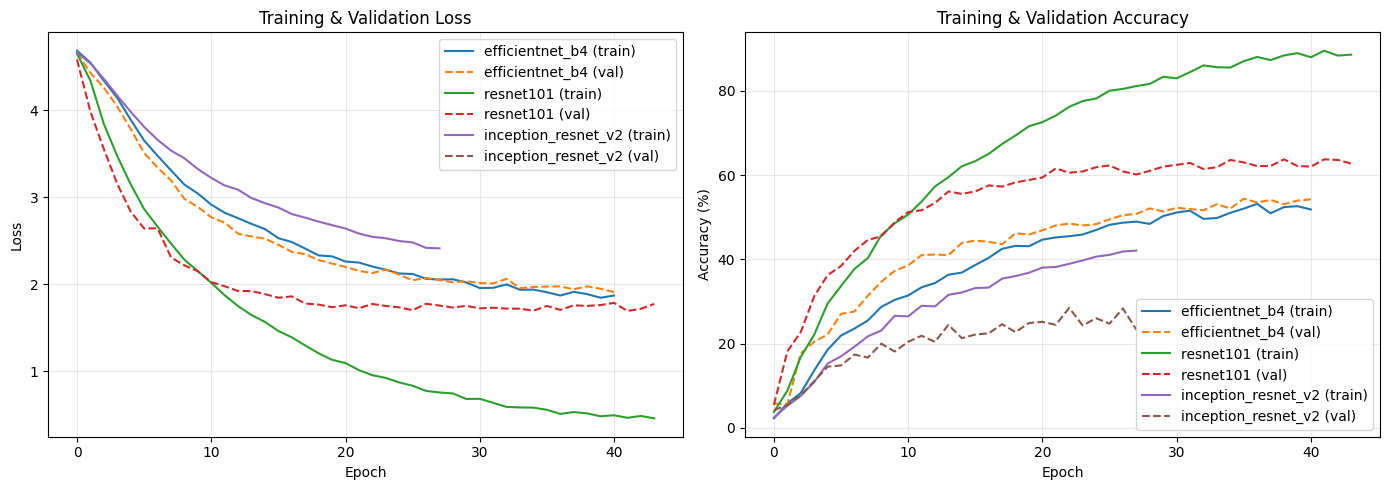

In [12]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, history in all_histories.items():
    axes[0].plot(history['train_loss'], label=f"{model_name} (train)")
    axes[0].plot(history['val_loss'], '--', label=f"{model_name} (val)")
    
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for model_name, history in all_histories.items():
    axes[1].plot(history['train_acc'], label=f"{model_name} (train)")
    axes[1].plot(history['val_acc'], '--', label=f"{model_name} (val)")

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_curves.png', dpi=150)
plt.show()

## 11. Save Final Results

In [13]:
import json

results_summary = {
    'config': CONFIG,
    'num_classes': NUM_CLASSES,
    'train_size': len(X_train),
    'val_size': len(X_val),
    'test_size': len(X_test),
    'results': all_results
}

with open(SAVE_DIR / 'results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f"Results saved to {SAVE_DIR / 'results_summary.json'}")

Results saved to /kaggle/working/cnn_egypt_models/results_summary.json


---

## Fixes Applied in v2

1. **Gradient Clipping**: Added `torch.nn.utils.clip_grad_norm_()` with `max_norm=1.0` to prevent exploding gradients
2. **Lower LR for Inception**: Uses 0.5x learning rate multiplier for `inception_resnet_v2`
3. **NaN Handling**: Detects and replaces NaN values in predictions before computing top-k accuracy
4. **Updated AMP API**: Using `torch.amp` instead of deprecated `torch.cuda.amp`
5. **FP32 Softmax**: Converts outputs to float32 before softmax for numerical stability
6. **NaN Loss Detection**: Skips batches with NaN loss during training